<a href="https://colab.research.google.com/github/Popolishka1/Statistical-Natural-Language-Processing/blob/nora/Visualizing_Perturbations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Visualisations**

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import json
from transformers import AutoModelForCausalLM, AutoTokenizer

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cpu


In [10]:
# prompt: mount a google drive folder to access the data within, the data is in a shared with me file called SNLP

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
folder_path = '/content/drive/MyDrive/SNLP'


## Functions

### DetectGPT Discrepancy Calculation

In [5]:
def compute_detectgpt_discrepancy(log_probs_per_text_base: list,
                                log_probs_per_text_transformed: list,
                                normalization: bool=False) -> list:
    """
    Compute the DetectGPT discrepancy metric for each of the n_samples texts. Computed for n_perturbations perturbations.

    Args:
        log_probs_per_text_base (list): original log probability of each text
        log_probs_per_text_transformed (list): list of size n_samples where each element is a list of the n_perturbations perturbed log probs
        normalization (bool): True if you want to normalize the discrepancy scores, False otherwise

    Returns:
        discrepancy_scores (list): list of discrepancy values (d) for the n_samples texts
    """
    n_samples = len(log_probs_per_text_base)
    discrepancy_scores = []

    for i in range(n_samples):
        original_log_prob = log_probs_per_text_base[i]
        perturbed_log_probs = log_probs_per_text_transformed[i] # List of perturbed log probs

        # Compute mean log probability of the perturbed texts
        mu = np.mean(perturbed_log_probs)

        # Compute discrepancy
        discrepancy_score_unormalized = original_log_prob - mu
        if normalization:
            # Normalize
            sigma = np.std(perturbed_log_probs)
            discrepancy_score_normalized = discrepancy_score_unormalized / sigma if sigma > 0 else discrepancy_score_unormalized
            discrepancy_scores.append(discrepancy_score_normalized)
        else:
            discrepancy_scores.append(discrepancy_score_unormalized)

    return discrepancy_scores

### AUROC Calculation

In [6]:
def get_roc_metrics(discrepancy_scores_human, discrepancy_scores_ai):
    fpr, tpr, _ = roc_curve(
    np.array([0] * len(discrepancy_scores_human) + [1] * len(discrepancy_scores_ai)),
    np.concatenate([discrepancy_scores_human, discrepancy_scores_ai])
    )
    roc_auc = auc(fpr, tpr)
    return fpr.tolist(), tpr.tolist(), float(roc_auc)

### Histogram Grid

In [7]:
def plot_histogram_grid(list_of_scores, title, row_titles, col_titles, row_heading, col_heading):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle(title, fontsize=24, fontweight='bold', y=1.04)  # Title further away

    for i, ax in enumerate(axes.flat):
        human_scores = list_of_scores[i * 2]
        ai_scores = list_of_scores[i * 2 + 1]

        fpr,tpr,roc_auc = get_roc_metrics(human_scores, ai_scores)

        ax.hist(human_scores, bins='auto', alpha=0.5, label='Human', edgecolor='black')
        ax.hist(ai_scores, bins='auto', alpha=0.5, label='AI', edgecolor='black')


        ax.set_title(f'AUROC {roc_auc:.2f}')

        if i % 3 == 0:
            ax.set_ylabel('Frequency')
            ax.text(-0.25, 0.5, row_titles[i // 3], transform=ax.transAxes, fontsize=16, fontweight = 'bold',
                    rotation=90, verticalalignment='center', horizontalalignment='center')

        if i < 3:
            ax.text(0.5, 1.15, col_titles[i], transform=ax.transAxes, fontsize=16, fontweight = 'bold',
                    rotation='horizontal', verticalalignment='bottom', horizontalalignment='center')

        if i >= 6:
            ax.set_xlabel('Discrepancy Score')

        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig.text(-0.06, 0.5, row_heading, va='center', rotation='vertical', fontsize=20, fontweight = 'bold')  # Equidistant from grid
    fig.text(0.5, 0.95, col_heading, ha='center', fontsize=20, fontweight = 'bold')  # Centered relative to grid

    plt.show()

### AUROC Grid

In [8]:
def plot_auroc_grid(list_of_scores, title, row_titles, col_titles, row_heading, col_heading):
    aurocs = [get_roc_metrics(list_of_scores[i * 2], list_of_scores[i * 2 + 1])[2] for i in range(9)]

    fig, ax = plt.subplots(figsize=(6, 6))

    auroc_matrix = np.array(aurocs).reshape(3, 3)
    sns.heatmap(auroc_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax, cbar_kws={'label': 'AUROC'})

    ax.set_yticklabels(row_titles, fontsize=12, fontweight='bold', va='center', rotation=90)

    ax.set_xticklabels(col_titles, fontsize=12, fontweight='bold', ha='center', rotation=0)
    ax.xaxis.set_label_position('top')  # Move x-axis label (column titles) to the top
    ax.xaxis.tick_top()  # Ensure ticks and labels are on top

    # Set main title
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.08)

    # Set 'Scoring Model' and 'Generating Model' labels
    fig.text(0, 0.5, row_heading, va='center', rotation='vertical', fontsize=14, fontweight='bold')
    fig.text(0.5, 0.96, col_heading, ha='center', fontsize=14, fontweight='bold')

    plt.show()

## Data

### Import Data

In [13]:
# Define the expected keys and structure
EXPECTED_KEYS = {"log_probs_base", "log_probs_transformed", "discrepancy_scores"}

def load_and_validate(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    # Check that the JSON object has exactly the three expected keys
    if set(data.keys()) != EXPECTED_KEYS:
        raise ValueError(f"Expected keys {EXPECTED_KEYS}, but got {set(data.keys())}")
    # Validate lengths for each list
    if len(data["log_probs_base"]) != 200:
        raise ValueError("log_probs_base should contain 200 floats")
    if len(data["log_probs_transformed"]) != 200:
        raise ValueError("log_probs_transformed should contain 200 lists")
    if len(data["discrepancy_scores"]) != 200:
        raise ValueError("discrepancy_scores should contain 200 floats")
    # Validate each inner list in log_probs_transformed has 100 floats
    for idx, inner_list in enumerate(data["log_probs_transformed"]):
        if len(inner_list) != 100:
            raise ValueError(f"Inner list at index {idx} in log_probs_transformed does not contain 100 floats")
    return data




In [20]:
#GPT-J as SCORER and GENERATOR
ai_generated_by_gpt_j_computed_by_gpt_j_dct = load_and_validate(
    "/content/drive/MyDrive/SNLP/workspace/Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-j-6B__Perturbed_By_google-t5/t5-3b__Scored_By_EleutherAI/gpt-j-6B__20250318_175629.jsonl"
)

human_computed_by_gpt_j_gpt_j_run_dct = load_and_validate(
    "/content/drive/MyDrive/SNLP/workspace/Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_EleutherAI/gpt-j-6B__20250318_171708.jsonl"
)

In [22]:
#GPT-NEO as SCORER and GENERATOR

human_computed_by_gpt_neo_gpt_neo_run_dct = load_and_validate(
    "/content/drive/MyDrive/SNLP/workspace/Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_EleutherAI/gpt-neo-2.7B__20250318_203938.jsonl"
)

ai_generated_by_gpt_neo_computed_by_gpt_neo_dct = load_and_validate(
"/content/drive/MyDrive/SNLP/workspace/Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-neo-2.7B__Perturbed_By_google-t5/t5-3b__Scored_By_EleutherAI/gpt-neo-2.7B__20250318_205825.jsonl")

In [29]:
#GPT-2-OLD
human_computed_by_gpt_2_gpt_2_run_dct_std = load_and_validate(
    "/content/drive/MyDrive/SNLP/workspace/Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2__20250319_120520.jsonl"
)

ai_generated_by_gpt_2_computed_by_gpt_2_dct_std = load_and_validate("/content/drive/MyDrive/SNLP/workspace/Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_openai-community/gpt2__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2__20250319_120717.jsonl")


# Visualize Log Probs


###Log_Probs_Base_Overlap


In [37]:
def calculate_overlap(data1, data2, bins=30):
    # Define the common range based on both datasets
    min_val = min(np.min(data1), np.min(data2))
    max_val = max(np.max(data1), np.max(data2))

    # Create histograms with density=True to approximate PDFs
    hist1, bin_edges = np.histogram(data1, bins=bins, range=(min_val, max_val), density=True)
    hist2, _ = np.histogram(data2, bins=bin_edges, density=True)

    # Compute the bin width (all bins have the same width)
    bin_width = bin_edges[1] - bin_edges[0]

    # The overlap is the sum of the minima in each bin multiplied by the bin width
    overlap_area = np.sum(np.minimum(hist1, hist2)) * bin_width
    return overlap_area, bin_edges, hist1, hist2

    import numpy as np


def plot_overlap_histogram(ai_log_probs, human_log_probs, title, bins=30):
    # Determine the common range for the histograms
    min_val = min(np.min(ai_log_probs), np.min(human_log_probs))
    max_val = max(np.max(ai_log_probs), np.max(human_log_probs))

    # Create histograms with density=True to estimate the PDFs
    hist_ai, bin_edges = np.histogram(ai_log_probs, bins=bins, range=(min_val, max_val), density=True)
    hist_human, _ = np.histogram(human_log_probs, bins=bin_edges, density=True)

    # Calculate the bin width (assuming equal-width bins)
    bin_width = bin_edges[1] - bin_edges[0]

    # Calculate the overlap area by summing the minima in each bin multiplied by the bin width
    overlap_area = np.sum(np.minimum(hist_ai, hist_human)) * bin_width

    # Plotting the histograms
    plt.figure(figsize=(8, 5))

    # Plot the estimated PDFs as step plots
    plt.step(bin_edges[:-1], hist_ai, where='post', label='AI', color='blue')
    plt.step(bin_edges[:-1], hist_human, where='post', label='Human', color='orange')

    # Shade the overlapping area
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    overlap_values = np.minimum(hist_ai, hist_human)
    plt.bar(bin_centers, overlap_values, width=bin_width, color='gray', alpha=0.5, label='Overlap')

    # Label the plot
    plt.xlabel("log_probs_base")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()

    # Print the overlap coefficient
    print("Overlap coefficient (area):", overlap_area)

    # Show the plot
    plt.show()



Overlap coefficient (area): 0.7949999999999999


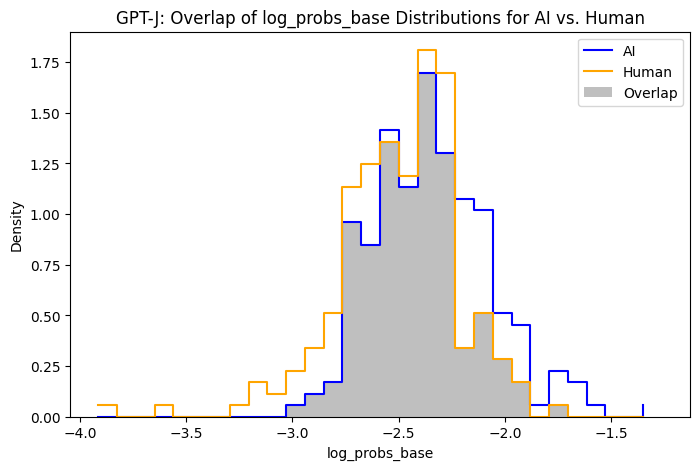

Overlap coefficient (area): 0.5700000000000021


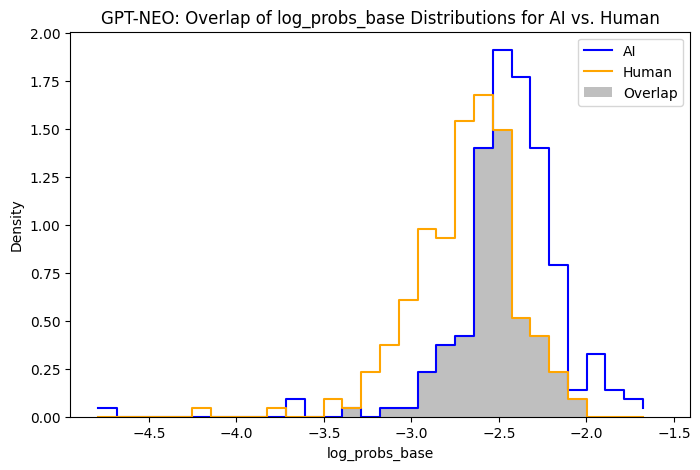

Overlap coefficient (area): 0.49500000000000044


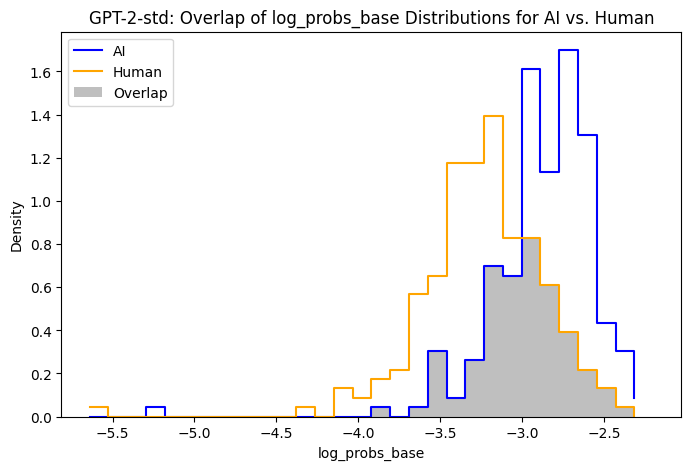

In [41]:
#GPT-J
plot_overlap_histogram(ai_generated_by_gpt_j_computed_by_gpt_j_dct["log_probs_base"], human_computed_by_gpt_j_gpt_j_run_dct["log_probs_base"], "GPT-J: Overlap of log_probs_base Distributions for AI vs. Human")
plot_overlap_histogram(ai_generated_by_gpt_neo_computed_by_gpt_neo_dct["log_probs_base"],
human_computed_by_gpt_neo_gpt_neo_run_dct["log_probs_base"], "GPT-NEO: Overlap of log_probs_base Distributions for AI vs. Human")
plot_overlap_histogram(ai_generated_by_gpt_2_computed_by_gpt_2_dct_std["log_probs_base"],
human_computed_by_gpt_2_gpt_2_run_dct_std["log_probs_base"],"GPT-2-std: Overlap of log_probs_base Distributions for AI vs. Human")

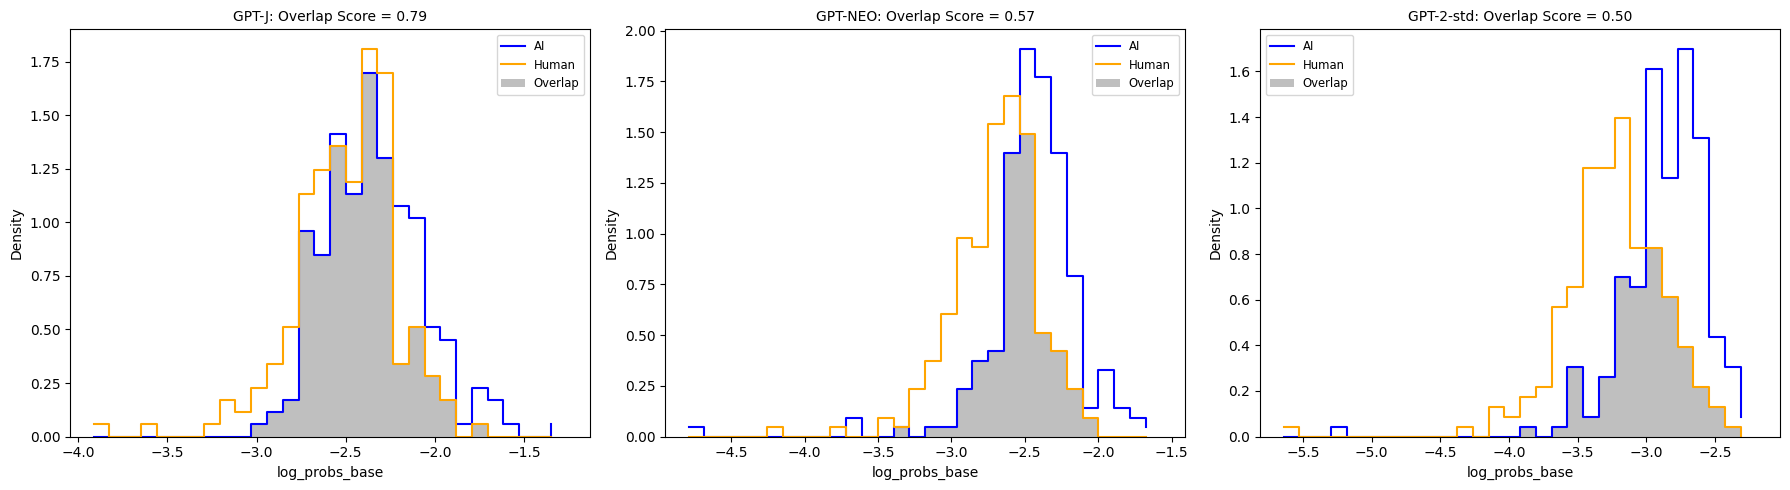

In [45]:
# @title
#FULL OVERLAP

def plot_overlap_histogram_subplot(ax, ai_log_probs, human_log_probs, model_name, bins=30):
    # Determine the common range for the histograms
    min_val = min(np.min(ai_log_probs), np.min(human_log_probs))
    max_val = max(np.max(ai_log_probs), np.max(human_log_probs))

    # Compute histograms (density=True for PDF estimates)
    hist_ai, bin_edges = np.histogram(ai_log_probs, bins=bins, range=(min_val, max_val), density=True)
    hist_human, _ = np.histogram(human_log_probs, bins=bin_edges, density=True)

    # Compute bin width and bin centers
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Calculate overlap: sum of the minimum densities in each bin multiplied by the bin width
    overlap_area = np.sum(np.minimum(hist_ai, hist_human)) * bin_width

    # Plot the histograms as step plots
    ax.step(bin_edges[:-1], hist_ai, where='post', label='AI', color='blue')
    ax.step(bin_edges[:-1], hist_human, where='post', label='Human', color='orange')

    # Shade the overlapping area
    overlap_values = np.minimum(hist_ai, hist_human)
    ax.bar(bin_centers, overlap_values, width=bin_width, color='gray', alpha=0.5, label='Overlap')

    # Set labels and title with model name and overlap score
    ax.set_xlabel("log_probs_base")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name}: Overlap Score = {overlap_area:.2f}", fontsize=10)

    # Add legend
    ax.legend(fontsize='small')

    return overlap_area

# Create a figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot each histogram on its respective subplot with the updated title format
overlap_j = plot_overlap_histogram_subplot(
    axs[0],
    ai_generated_by_gpt_j_computed_by_gpt_j_dct["log_probs_base"],
    human_computed_by_gpt_j_gpt_j_run_dct["log_probs_base"],
    "GPT-J"
)

overlap_neo = plot_overlap_histogram_subplot(
    axs[1],
    ai_generated_by_gpt_neo_computed_by_gpt_neo_dct["log_probs_base"],
    human_computed_by_gpt_neo_gpt_neo_run_dct["log_probs_base"],
    "GPT-NEO"
)

overlap_2 = plot_overlap_histogram_subplot(
    axs[2],
    ai_generated_by_gpt_2_computed_by_gpt_2_dct_std["log_probs_base"],
    human_computed_by_gpt_2_gpt_2_run_dct_std["log_probs_base"],
    "GPT-2-std"
)

plt.tight_layout()
# Save the figure to a file (e.g., "overlap_histograms.png")
plt.savefig("overlap_histograms.png", dpi=300, bbox_inches='tight')
plt.show()


Overlap is calculated by taking (for each bin) the minimimum density between the

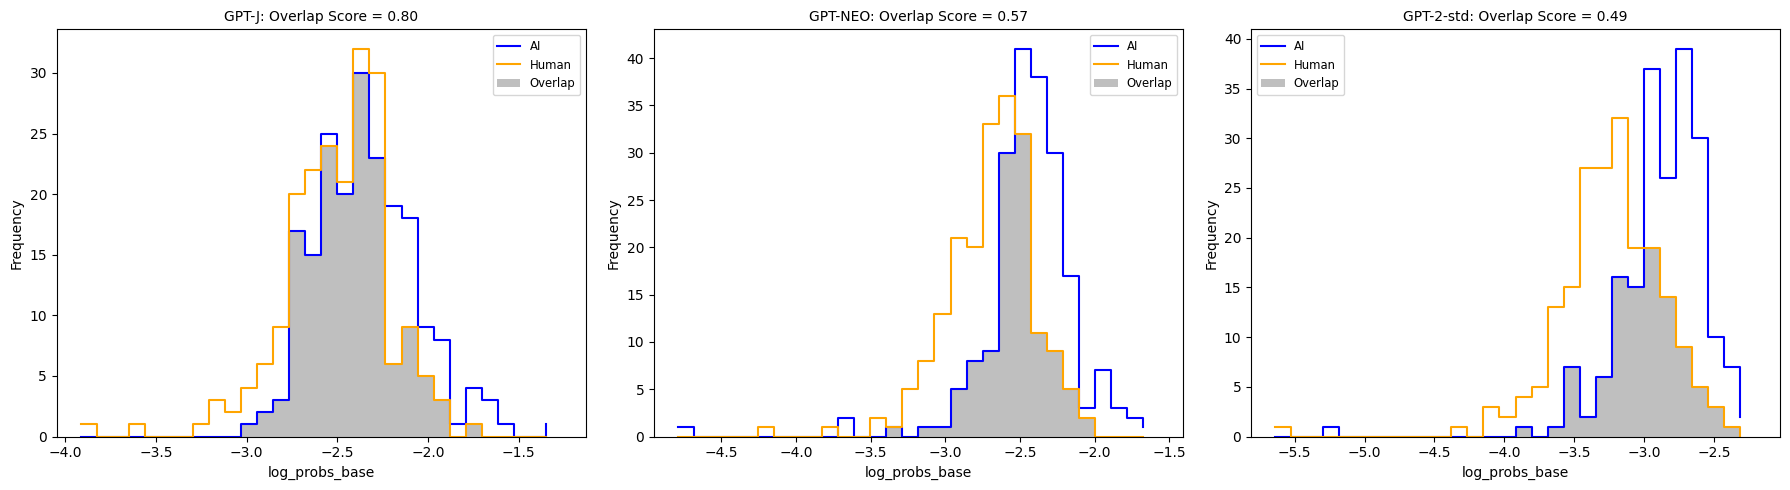

In [46]:
# @title
import numpy as np
import matplotlib.pyplot as plt

def plot_overlap_histogram_subplot(ax, ai_log_probs, human_log_probs, model_name, bins=30):
    # Determine the common range for the histograms
    min_val = min(np.min(ai_log_probs), np.min(human_log_probs))
    max_val = max(np.max(ai_log_probs), np.max(human_log_probs))

    # Compute histograms using raw counts (density is False by default)
    hist_ai, bin_edges = np.histogram(ai_log_probs, bins=bins, range=(min_val, max_val))
    hist_human, _ = np.histogram(human_log_probs, bins=bin_edges)

    # Compute bin width and bin centers
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Calculate the overlap count: for each bin, take the minimum count from both histograms
    overlap_count = np.sum(np.minimum(hist_ai, hist_human))
    # Normalize the overlap count by the total sample size (200) to get a fraction between 0 and 1
    overlap_score = overlap_count / 200.0

    # Plot the histograms as step plots (raw counts)
    ax.step(bin_edges[:-1], hist_ai, where='post', label='AI', color='blue')
    ax.step(bin_edges[:-1], hist_human, where='post', label='Human', color='orange')

    # Shade the overlapping area between the histograms
    overlap_values = np.minimum(hist_ai, hist_human)
    ax.bar(bin_centers, overlap_values, width=bin_width, color='gray', alpha=0.5, label='Overlap')

    # Set labels and title with the model name and overlap score
    ax.set_xlabel("log_probs_base")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{model_name}: Overlap Score = {overlap_score:.2f}", fontsize=10)

    # Add legend to the subplot
    ax.legend(fontsize='small')

    return overlap_score

# Create a figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot each histogram on its respective subplot with the updated settings for raw counts
overlap_j = plot_overlap_histogram_subplot(
    axs[0],
    ai_generated_by_gpt_j_computed_by_gpt_j_dct["log_probs_base"],
    human_computed_by_gpt_j_gpt_j_run_dct["log_probs_base"],
    "GPT-J"
)

overlap_neo = plot_overlap_histogram_subplot(
    axs[1],
    ai_generated_by_gpt_neo_computed_by_gpt_neo_dct["log_probs_base"],
    human_computed_by_gpt_neo_gpt_neo_run_dct["log_probs_base"],
    "GPT-NEO"
)

overlap_2 = plot_overlap_histogram_subplot(
    axs[2],
    ai_generated_by_gpt_2_computed_by_gpt_2_dct_std["log_probs_base"],
    human_computed_by_gpt_2_gpt_2_run_dct_std["log_probs_base"],
    "GPT-2-std"
)

plt.tight_layout()

# Save the figure to a file (this file will be saved in the current working directory, usually /content/ in Colab)
plt.savefig("overlap_histograms_raw_counts.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.show()


Overlap Calculation:

For each bin, the code takes the minimum of the two counts (one from AI and one from Human).

The sum of these minimum values gives the total count of overlapping data in the bins.

Dividing by 200 (the number of samples) normalizes this value into a fraction between 0 (no overlap) and 1 (complete overlap).

### Old Methodology


In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_closest_pair_transformed(ai_data, human_data, rank=1, bins=20):
    """
    For the GPT-Neo data provided in ai_data and human_data (each a dict with keys
    "log_probs_base" and "log_probs_transformed"), this function:
      1. Computes the absolute differences between the AI and Human log_probs_base values.
      2. Sorts the sample pairs by these differences.
      3. Selects the pair at the given rank (rank=1 for the closest pair).
      4. Plots an overlapping histogram of the 100 log_probs_transformed values for the selected pair.
      5. Draws a vertical line at the mean of the two log_probs_base values.
      6. Prints the sample index, mean log_probs_base, and the difference.
    """
    # Extract base values
    ai_bases = np.array(ai_data["log_probs_base"])
    human_bases = np.array(human_data["log_probs_base"])

    # Compute the absolute differences for each sample
    diff_array = np.abs(ai_bases - human_bases)

    # Get sorted indices (smallest difference first)
    sorted_indices = np.argsort(diff_array)

    # Select the sample index corresponding to the given rank (1-indexed)
    if rank > len(sorted_indices):
        raise ValueError(f"Rank {rank} exceeds number of samples ({len(sorted_indices)})")
    idx = sorted_indices[rank - 1]

    # Get the two base values and compute mean and difference
    ai_base_val = ai_bases[idx]
    human_base_val = human_bases[idx]
    mean_base = (ai_base_val + human_base_val) / 2.0
    diff_base = abs(ai_base_val - human_base_val)

    # Print the values
    print(f"Selected sample index: {idx}")
    print(f"AI log_probs_base: {ai_base_val:.4f}, Human log_probs_base: {human_base_val:.4f}")
    print(f"Mean log_probs_base: {mean_base:.4f}")
    print(f"Difference in log_probs_base: {diff_base:.4f}")

    # Extract the corresponding inner lists of log_probs_transformed (each of length 100)
    ai_transformed = ai_data["log_probs_transformed"][idx]
    human_transformed = human_data["log_probs_transformed"][idx]

    # Determine a common range for the histograms
    min_val = min(min(ai_transformed), min(human_transformed))
    max_val = max(max(ai_transformed), max(human_transformed))
    bins_arr = np.linspace(min_val, max_val, bins)

    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.hist(ai_transformed, bins=bins_arr, alpha=0.5, label="AI Perturbated log_probs", color="blue")
    plt.hist(human_transformed, bins=bins_arr, alpha=0.5, label="Human Perturbated log_probs", color="orange")

    # Draw a vertical line for the mean log_probs_base (annotated)
    plt.axvline(mean_base, color='green', linestyle='--', label=f"Mean log_probs_base = {mean_base:.2f}")

    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"GPT-Neo Sample {idx} (Rank {rank}): Diff = {diff_base:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
# For GPT-Neo, assuming you have already loaded the dictionaries:
# ai_generated_by_gpt_neo_computed_by_gpt_neo_dct
# human_computed_by_gpt_neo_gpt_neo_run_dct



Selected sample index: 42
AI log_probs_base: -2.6479, Human log_probs_base: -2.6477
Mean log_probs_base: -2.6478
Difference in log_probs_base: 0.0002


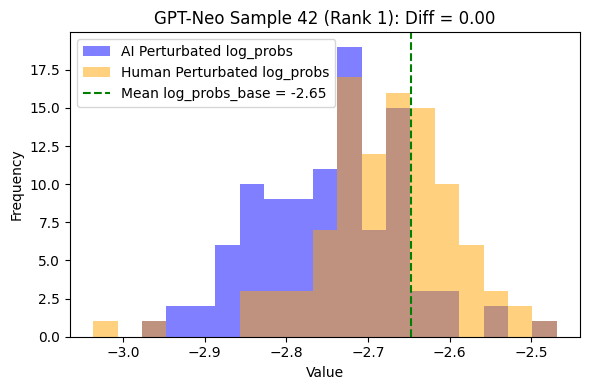

In [55]:
# Plot the closest pair (rank 1)
plot_closest_pair_transformed(ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                              human_computed_by_gpt_neo_gpt_neo_run_dct,
                              rank=1, bins=20)




In [52]:
|import numpy as np
import matplotlib.pyplot as plt

def plot_closest_pair_transformed_ranked(ai_data, human_data, rank=1, bins=20):
    """
    For GPT-Neo data provided in ai_data and human_data (each a dict with keys
    "log_probs_base" and "log_probs_transformed"), this function:
      1. Computes the pairwise absolute differences between every AI and every Human log_probs_base.
      2. Ranks all pairs by these differences.
      3. Selects the pair corresponding to the given rank (rank=1 for the closest pair overall).
      4. Plots an overlapping histogram of the 100 log_probs_transformed values for the selected pair.
      5. Draws a vertical dashed line at the mean of the two log_probs_base values.
      6. Prints the selected AI index, Human index, their base values, the mean, and the difference.
    """
    # Convert log_probs_base lists to NumPy arrays.
    ai_bases = np.array(ai_data["log_probs_base"])   # shape (n,)
    human_bases = np.array(human_data["log_probs_base"])  # shape (n,)

    # Compute a 2D matrix of absolute differences for all pairs.
    diff_matrix = np.abs(ai_bases[:, None] - human_bases[None, :])

    # Flatten the matrix and get the sorted indices (lowest difference first).
    # np.argsort(diff_matrix, axis=None) returns flattened indices sorted by difference.
    sorted_flat_indices = np.argsort(diff_matrix, axis=None)

    # Retrieve the AI and Human indices corresponding to the rank-th smallest difference.
    # Unravel the flattened index to get the 2D coordinates.
    ai_index, human_index = np.unravel_index(sorted_flat_indices[rank - 1], diff_matrix.shape)

    # Get the corresponding base values.
    ai_base_val = ai_bases[ai_index]
    human_base_val = human_bases[human_index]
    mean_base = (ai_base_val + human_base_val) / 2.0
    min_diff = diff_matrix[ai_index, human_index]

    # Print details.
    print(f"Selected pair (Rank {rank}):")
    print(f"  AI index: {ai_index}, Human index: {human_index}")
    print(f"  AI log_probs_base: {ai_base_val:.4f}, Human log_probs_base: {human_base_val:.4f}")
    print(f"  Mean log_probs_base: {mean_base:.4f}")
    print(f"  Difference in log_probs_base: {min_diff:.4f}")

    # Extract the corresponding inner lists of log_probs_transformed (each containing 100 values).
    ai_transformed = ai_data["log_probs_transformed"][ai_index]
    human_transformed = human_data["log_probs_transformed"][human_index]

    # Determine a common range for the histograms.
    min_val = min(min(ai_transformed), min(human_transformed))
    max_val = max(max(ai_transformed), max(human_transformed))
    bins_arr = np.linspace(min_val, max_val, bins)

    # Plot overlapping histograms.
    plt.figure(figsize=(6, 4))
    plt.hist(ai_transformed, bins=bins_arr, alpha=0.5, label=f"AI Sample {ai_index}", color="blue")
    plt.hist(human_transformed, bins=bins_arr, alpha=0.5, label=f"Human Sample {human_index}", color="orange")

    # Draw a vertical dashed line at the mean log_probs_base.
    plt.axvline(mean_base, color='green', linestyle='--', label=f"Mean log_probs_base = {mean_base:.2f}")

    plt.xlabel("log_probs_transformed")
    plt.ylabel("Frequency")
    plt.title(f"GPT-Neo Pair: AI {ai_index} vs. Human {human_index} (Diff = {min_diff:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.show()




Selected pair (Rank 1):
  AI index: 6, Human index: 88
  AI log_probs_base: -2.4102, Human log_probs_base: -2.4102
  Mean log_probs_base: -2.4102
  Difference in log_probs_base: 0.0000


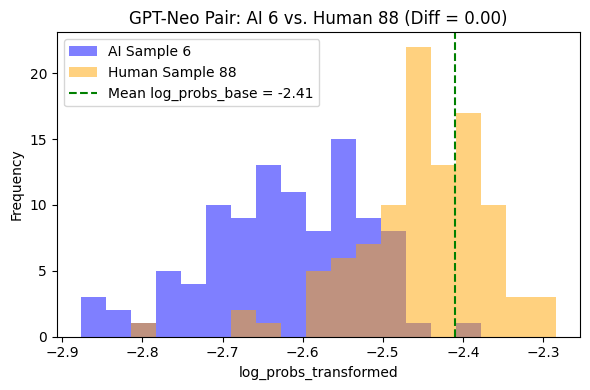

Selected pair (Rank 2):
  AI index: 25, Human index: 67
  AI log_probs_base: -2.6002, Human log_probs_base: -2.6002
  Mean log_probs_base: -2.6002
  Difference in log_probs_base: 0.0000


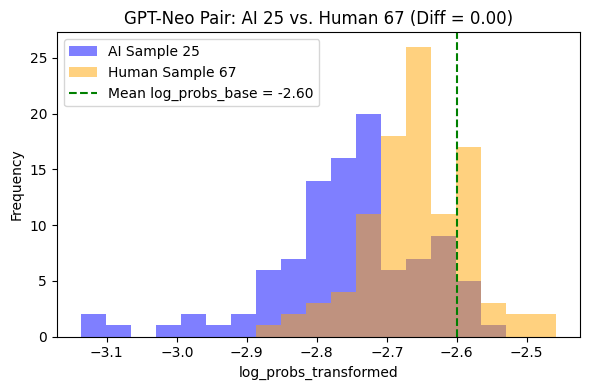

Selected pair (Rank 3):
  AI index: 111, Human index: 76
  AI log_probs_base: -2.7509, Human log_probs_base: -2.7510
  Mean log_probs_base: -2.7509
  Difference in log_probs_base: 0.0001


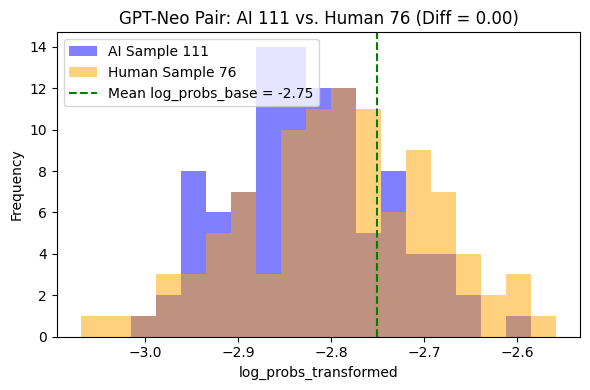

<Figure size 640x480 with 0 Axes>

In [56]:
# Example usage for GPT-Neo data:
# (Assuming the dictionaries ai_generated_by_gpt_neo_computed_by_gpt_neo_dct and
#  human_computed_by_gpt_neo_gpt_neo_run_dct have been loaded using your load_and_validate function)
plot_closest_pair_transformed_ranked(ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                     human_computed_by_gpt_neo_gpt_neo_run_dct,
                                     rank=1, bins=20)

plot_closest_pair_transformed_ranked(ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                     human_computed_by_gpt_neo_gpt_neo_run_dct,
                                     rank=2, bins=20)


plot_closest_pair_transformed_ranked(ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                     human_computed_by_gpt_neo_gpt_neo_run_dct,
                                     rank=3, bins=20)
# To plot the second closest pair, set rank=2, etc.

# Save the figure to a file (this file will be saved in the current working directory, usually /content/ in Colab)
plt.savefig("gpt-neo_pairs.png", dpi=300, bbox_inches='tight')

###Pair-wise visualization of perturbations


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_closest_pair_transformed_subplot(ax, ai_data, human_data, rank=1, bins=20):
    """
    For GPT-Neo data provided in ai_data and human_data (each a dict with keys:
      "log_probs_base" and "log_probs_transformed"),
    this function:
      1. Computes the pairwise absolute differences between every AI and every Human log_probs_base.
      2. Ranks all pairs by these differences.
      3. Selects the pair corresponding to the given rank (1-indexed).
      4. Plots an overlapping histogram of the 100 log_probs_transformed values for the selected pair on the provided axis.
      5. Draws vertical dashed lines for:
            - The mean of log_probs_base (green)
            - The mean of AI log_probs_transformed (red)
            - The mean of Human log_probs_transformed (purple)
      6. Annotates the subplot with details in small font below the plot.
    Returns a dictionary of the computed statistics.
    """
    # Convert base lists to numpy arrays.
    ai_bases = np.array(ai_data["log_probs_base"])
    human_bases = np.array(human_data["log_probs_base"])

    # Compute all pairwise absolute differences.
    diff_matrix = np.abs(ai_bases[:, None] - human_bases[None, :])

    # Flatten and sort differences.
    sorted_flat_indices = np.argsort(diff_matrix, axis=None)

    # Get the indices for the rank-th smallest difference.
    ai_index, human_index = np.unravel_index(sorted_flat_indices[rank - 1], diff_matrix.shape)

    # Retrieve base values and compute mean and difference.
    ai_base_val = ai_bases[ai_index]
    human_base_val = human_bases[human_index]
    mean_base = (ai_base_val + human_base_val) / 2.0
    base_diff = diff_matrix[ai_index, human_index]

    # Extract corresponding inner lists of log_probs_transformed (each of length 100).
    ai_transformed = ai_data["log_probs_transformed"][ai_index]
    human_transformed = human_data["log_probs_transformed"][human_index]

    # Compute means for transformed values.
    mean_trans_ai = np.mean(ai_transformed)
    mean_trans_human = np.mean(human_transformed)

    # Determine common histogram bins.
    min_val = min(min(ai_transformed), min(human_transformed))
    max_val = max(max(ai_transformed), max(human_transformed))
    bins_arr = np.linspace(min_val, max_val, bins)

    # Plot overlapping histograms.
    ax.hist(ai_transformed, bins=bins_arr, alpha=0.5, label=f"AI (Sample {ai_index})", color="blue")
    ax.hist(human_transformed, bins=bins_arr, alpha=0.5, label=f"Human (Sample {human_index})", color="orange")

    # Draw vertical dashed line for mean log_probs_base (green).
    ax.axvline(mean_base, color='black', linestyle='-', linewidth=1.9)
    # Draw vertical dashed line for mean AI log_probs_transformed (red).
    ax.axvline(mean_trans_ai, color='blue', linestyle='--', linewidth=1.5)
    # Draw vertical dashed line for mean Human log_probs_transformed (purple).
    ax.axvline(mean_trans_human, color='orange', linestyle='--', linewidth=1.5)

    # Set labels and title.
    ax.set_xlabel("log_probs_transformed")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Rank {rank}: Diff = {base_diff:.2f}", fontsize=10)

    # Prepare details text in small font.
    details = (f"AI idx: {ai_index}, Human idx: {human_index}\n"
               f"AI base: {ai_base_val:.4f}, Human base: {human_base_val:.4f}\n"
               f"Mean base: {mean_base:.4f}\n"
               f"Mean AI trans: {mean_trans_ai:.4f}, Mean Human trans: {mean_trans_human:.4f}")
    ax.text(0.5, -0.25, details, transform=ax.transAxes, fontsize=8, ha='center', va='top')

    # Return statistics in case further processing is desired.
    return {
        "ai_index": ai_index,
        "human_index": human_index,
        "ai_base": ai_base_val,
        "human_base": human_base_val,
        "mean_base": mean_base,
        "base_diff": base_diff,
        "mean_trans_ai": mean_trans_ai,
        "mean_trans_human": mean_trans_human
    }



####GPT-NEO

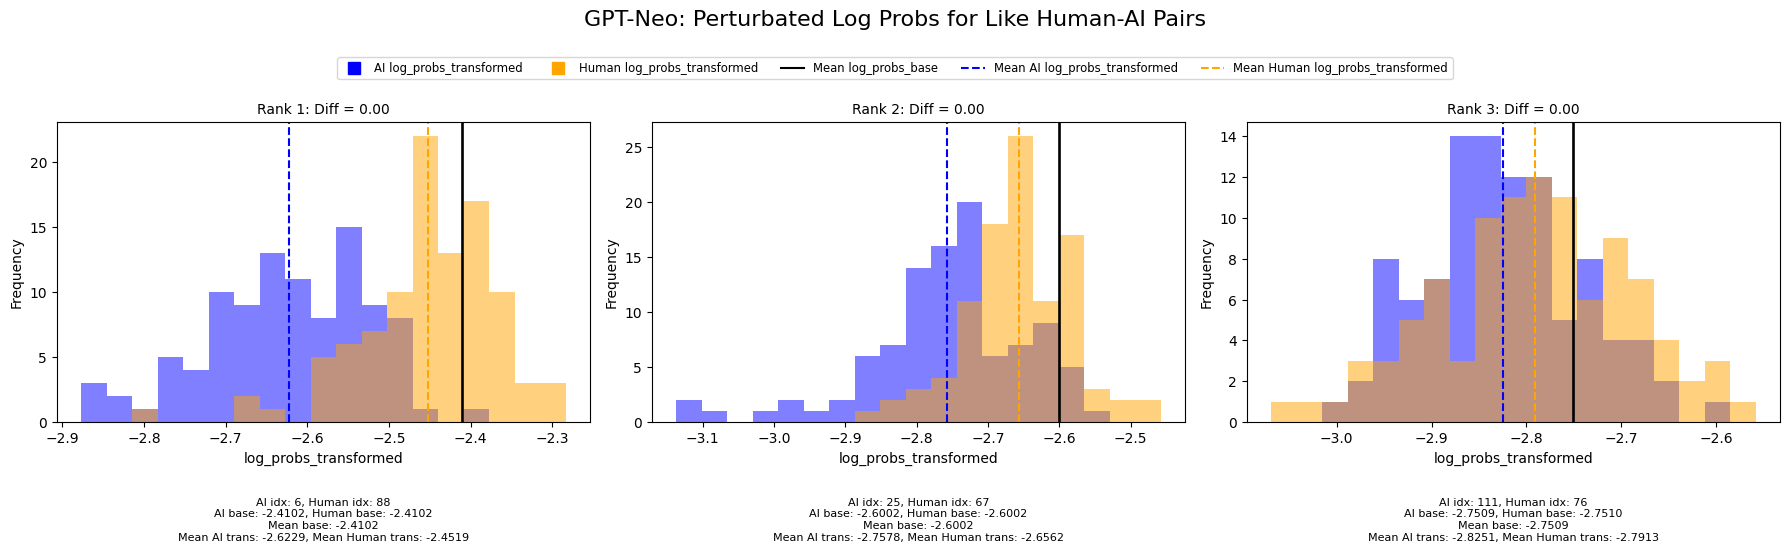

In [78]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=1, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=2, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=3, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-Neo: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-neo_pairs.png", dpi=300, bbox_inches='tight')
plt.show()

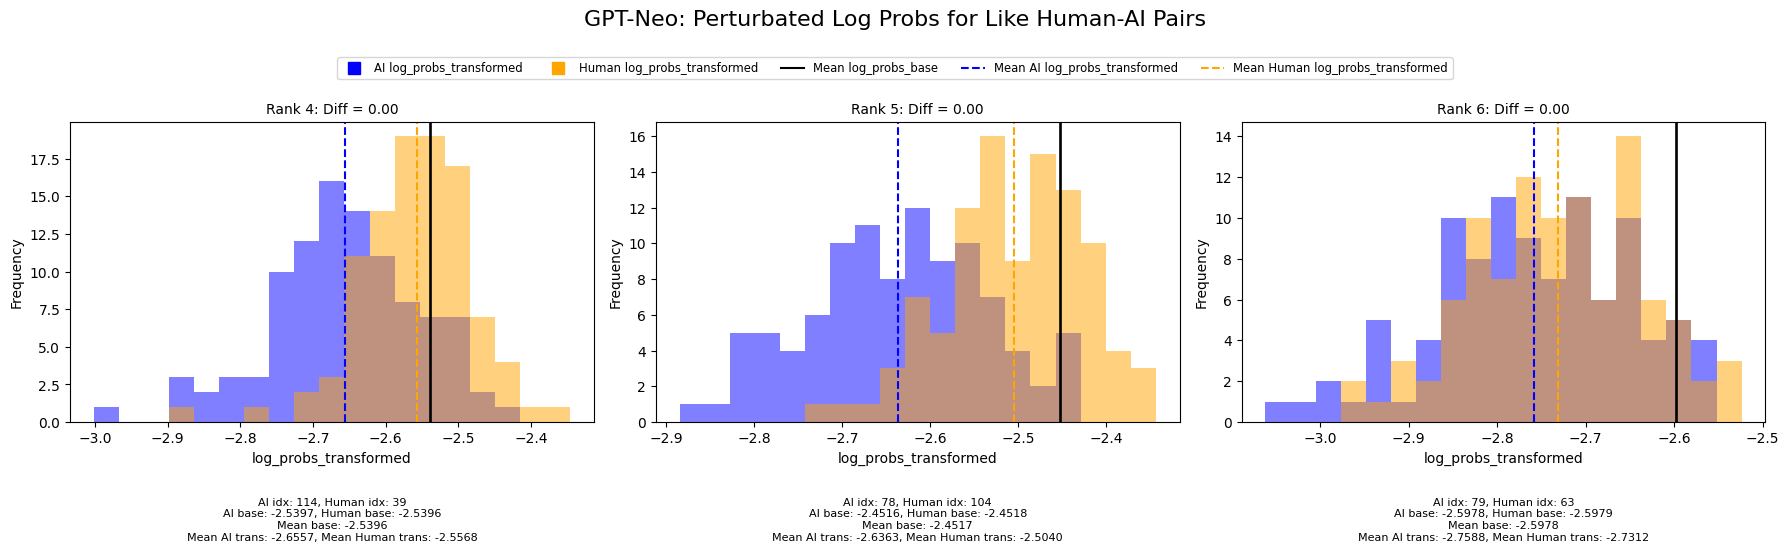

In [79]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=4, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=5, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_neo_computed_by_gpt_neo_dct,
                                               human_computed_by_gpt_neo_gpt_neo_run_dct,
                                               rank=6, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-Neo: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-neo_pairs2.png", dpi=300, bbox_inches='tight')
plt.show()

####GPT-J####

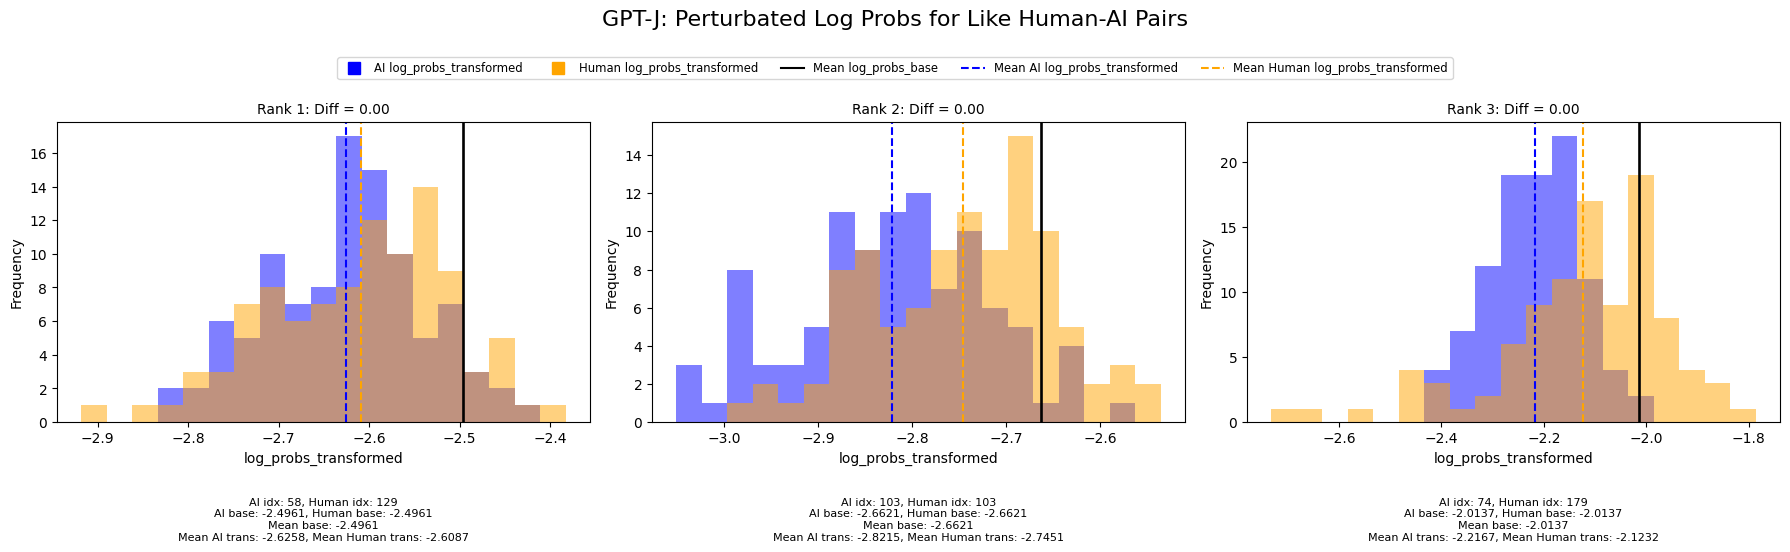

In [80]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=1, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=2, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=3, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-J: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-j_pairs.png", dpi=300, bbox_inches='tight')
plt.show()

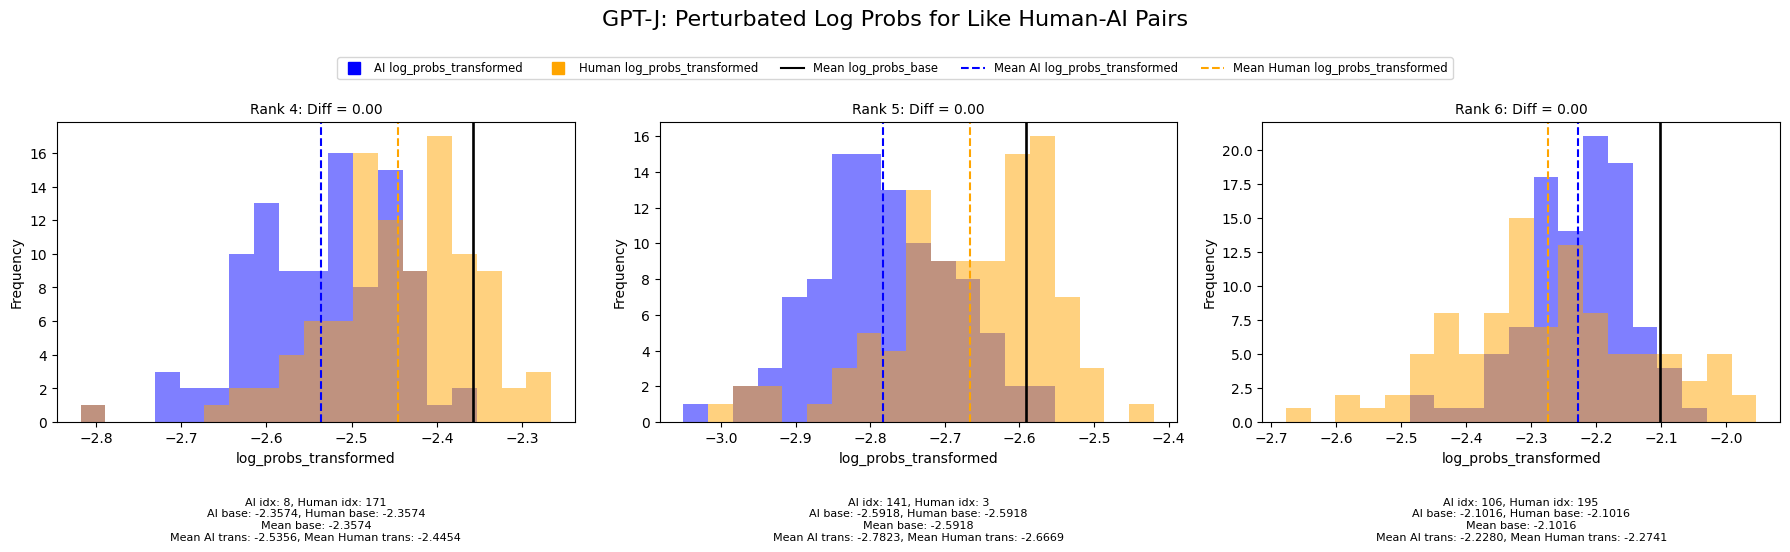

In [81]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=4, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=5, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_j_computed_by_gpt_j_dct,
                                               human_computed_by_gpt_j_gpt_j_run_dct,
                                               rank=6, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-J: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-j_pairs2.png", dpi=300, bbox_inches='tight')
plt.show()

####GPT-2-std####

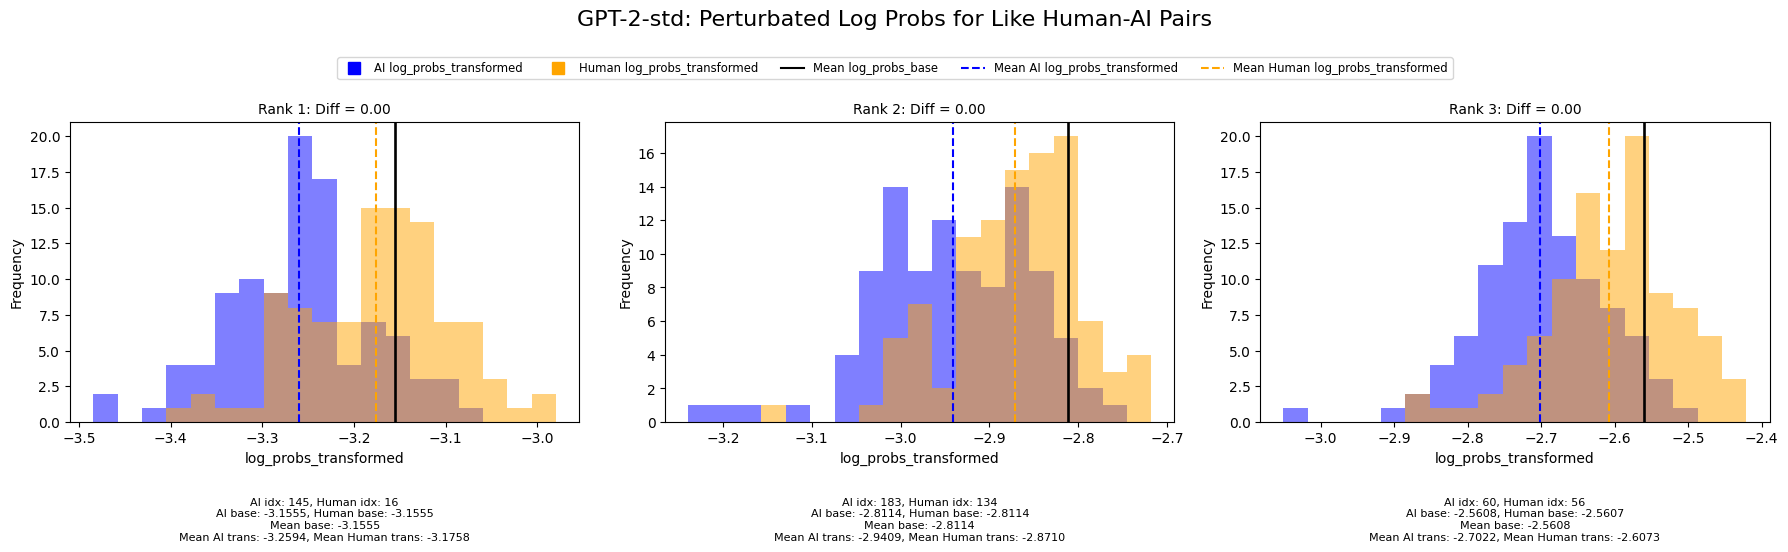

In [82]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=1, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=2, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=3, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-2-std: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-2_pairs.png", dpi=300, bbox_inches='tight')
plt.show()

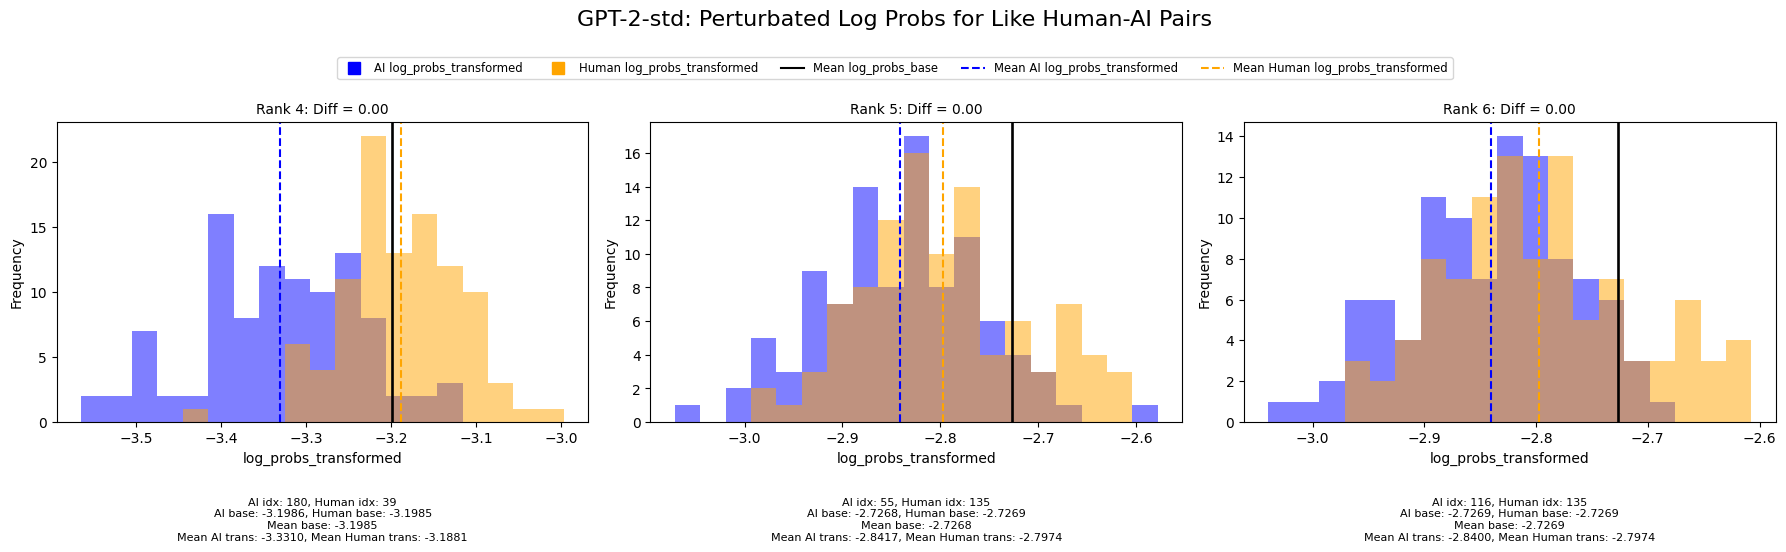

In [83]:
# @title
# Create a figure with 3 subplots side by side.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the ranked pairs (ranks 1, 2, and 3) for GPT-Neo.
stats1 = plot_closest_pair_transformed_subplot(axs[0],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=4, bins=20)
stats2 = plot_closest_pair_transformed_subplot(axs[1],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=5, bins=20)
stats3 = plot_closest_pair_transformed_subplot(axs[2],
                                               ai_generated_by_gpt_2_computed_by_gpt_2_dct_std,
                                               human_computed_by_gpt_2_gpt_2_run_dct_std,
                                               rank=6, bins=20)

# Adjust layout to leave room at the top for the title and legend.
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Add an overarching title.
fig.suptitle("GPT-2-std: Perturbated Log Probs for Like Human-AI Pairs", fontsize=16, y=0.98)

# Create dummy line objects for a single global legend.
handle_ai = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=8, label='AI log_probs_transformed')
handle_human = mlines.Line2D([], [], color='orange', marker='s', linestyle='None', markersize=8, label='Human log_probs_transformed')
handle_mean_base = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, label='Mean log_probs_base')
handle_mean_ai = mlines.Line2D([], [], color='blue', linestyle='--', linewidth=1.5, label='Mean AI log_probs_transformed')
handle_mean_human = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.5, label='Mean Human log_probs_transformed')

# Place the global legend below the title, ensuring it doesn't overlap.
fig.legend(handles=[handle_ai, handle_human, handle_mean_base, handle_mean_ai, handle_mean_human],
           loc='upper center', ncol=5, fontsize='small', bbox_to_anchor=(0.5, 0.91))

# Save the figure to a file (this will be saved in /content/ in Colab by default).
plt.savefig("gpt-2_pairs2.png", dpi=300, bbox_inches='tight')
plt.show()

#### Observations




1.   Human and AI-generated text seem to have more overlap in baseline average log_probs than expected, particularly for GPT-J (79% overlap)
2.   For both human and AI-generated text, on average perturbated samples have lower log_prob than the original (when perturbating on 3rd model T5-3B)
3. In majority of instances, perturbated samples from AI original text have a lower center of density than perturbated samples from human text, even if the base log_prob is nearly identical
4. Observationally, it is difficult to identify clear cutoff that would be agnostic of samples -e.g., you have to run this experiment across a variety of samples to get a sense of the trend




